In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import matplotlib as mpl
mpl.rcParams['font.family'] = 'monospace' 

from scipy.ndimage import gaussian_filter
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker
from matplotlib.colors import Normalize
import sys
import os
sys.path.append(os.path.abspath('..'))
from scripts import analysis_utils as au

In [24]:
# data = np.concatenate((np.loadtxt('all_harmonics_output.txt'), 
#                       np.loadtxt('2025_11_22_injections.txt'),
#                       np.loadtxt('2025_11_28_injections.txt')))
#data = data[np.isin(data[:, 2], [20251113.20251116.20251119.0])]
data = np.loadtxt('stack_injections_3_27_26.txt')
print(f'Number of pointings: {len(np.unique(data[:, 0:2], axis=0))}')
#print(f'Number of days: {len(np.unique(data[:, 2]))}')
print(f'Number of days: {np.unique(data[:, 2], axis = 0)}')
print(f'Total fraction of recovered injections: {(100*len(data[data[:, -1] > 0.])/len(data)):.2f}%')
print(f'Number of injections: {len(data)}')
RA = data[:, 0]
Dec = data[:, 1]
f = data[:, 4]
DM = data[:, 5]
S = data[:, 6]
fwhm = data[:, 7]
# TPA_idx = data[:, 3].astype('int')
# fwhm_array = np.load('../profiles/TPA_fwhm.npy')
# fwhm = fwhm_array[TPA_idx]
# jitter = np.random.uniform(0.85, 1.15, size=len(fwhm)) #to deal with discrete FWHM
# data[:, 7] = fwhm * jitter

Number of pointings: 925
Number of days: [ 7.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 32. 45. 64.]
Total fraction of recovered injections: 7.46%
Number of injections: 8803


In [5]:
RA_bins = np.arange(min(RA), max(RA), 0.5)
Dec_bins = np.arange(min(Dec), max(Dec), 0.5)
f_bins = np.logspace(np.log10(min(f)), np.log10(max(f)), 1000)
DM_bins = np.arange(min(DM), 1000)
S_bins = np.logspace(np.log10(min(S)), np.log10(max(S)), 1000)
fwhm_bins = np.logspace(np.log10(min(fwhm)), np.log10(0.15), 1000)

In [6]:
f_dev = 50
DM_dev = 100
S_dev = 50
FWHM_dev = 80

In [18]:
_, _, ndays_ret_p_smooth = au.get_sensitivity(
    data,
    *(2, np.arange(7, 32, 3), 3)
)

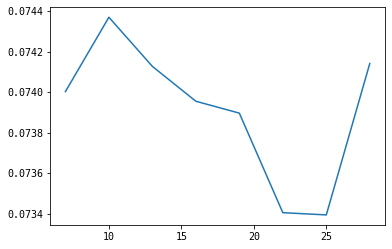

In [20]:
plt.plot(np.arange(7, 32, 3)[:-1], ndays_ret_p_smooth)

All data:

In [8]:
dm_f_inj_p_smooth, _, dm_f_ret_p_smooth = au.get_sensitivity(
    data,
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth, _, dm_s_ret_p_smooth = au.get_sensitivity(
    data,
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth, _, s_f_ret_p_smooth = au.get_sensitivity(
    data,
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth, _, s_fwhm_ret_p_smooth = au.get_sensitivity(
    data,
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth, _, dm_fwhm_ret_p_smooth = au.get_sensitivity(
    data,
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth, _, fwhm_f_ret_p_smooth = au.get_sensitivity(
    data,
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

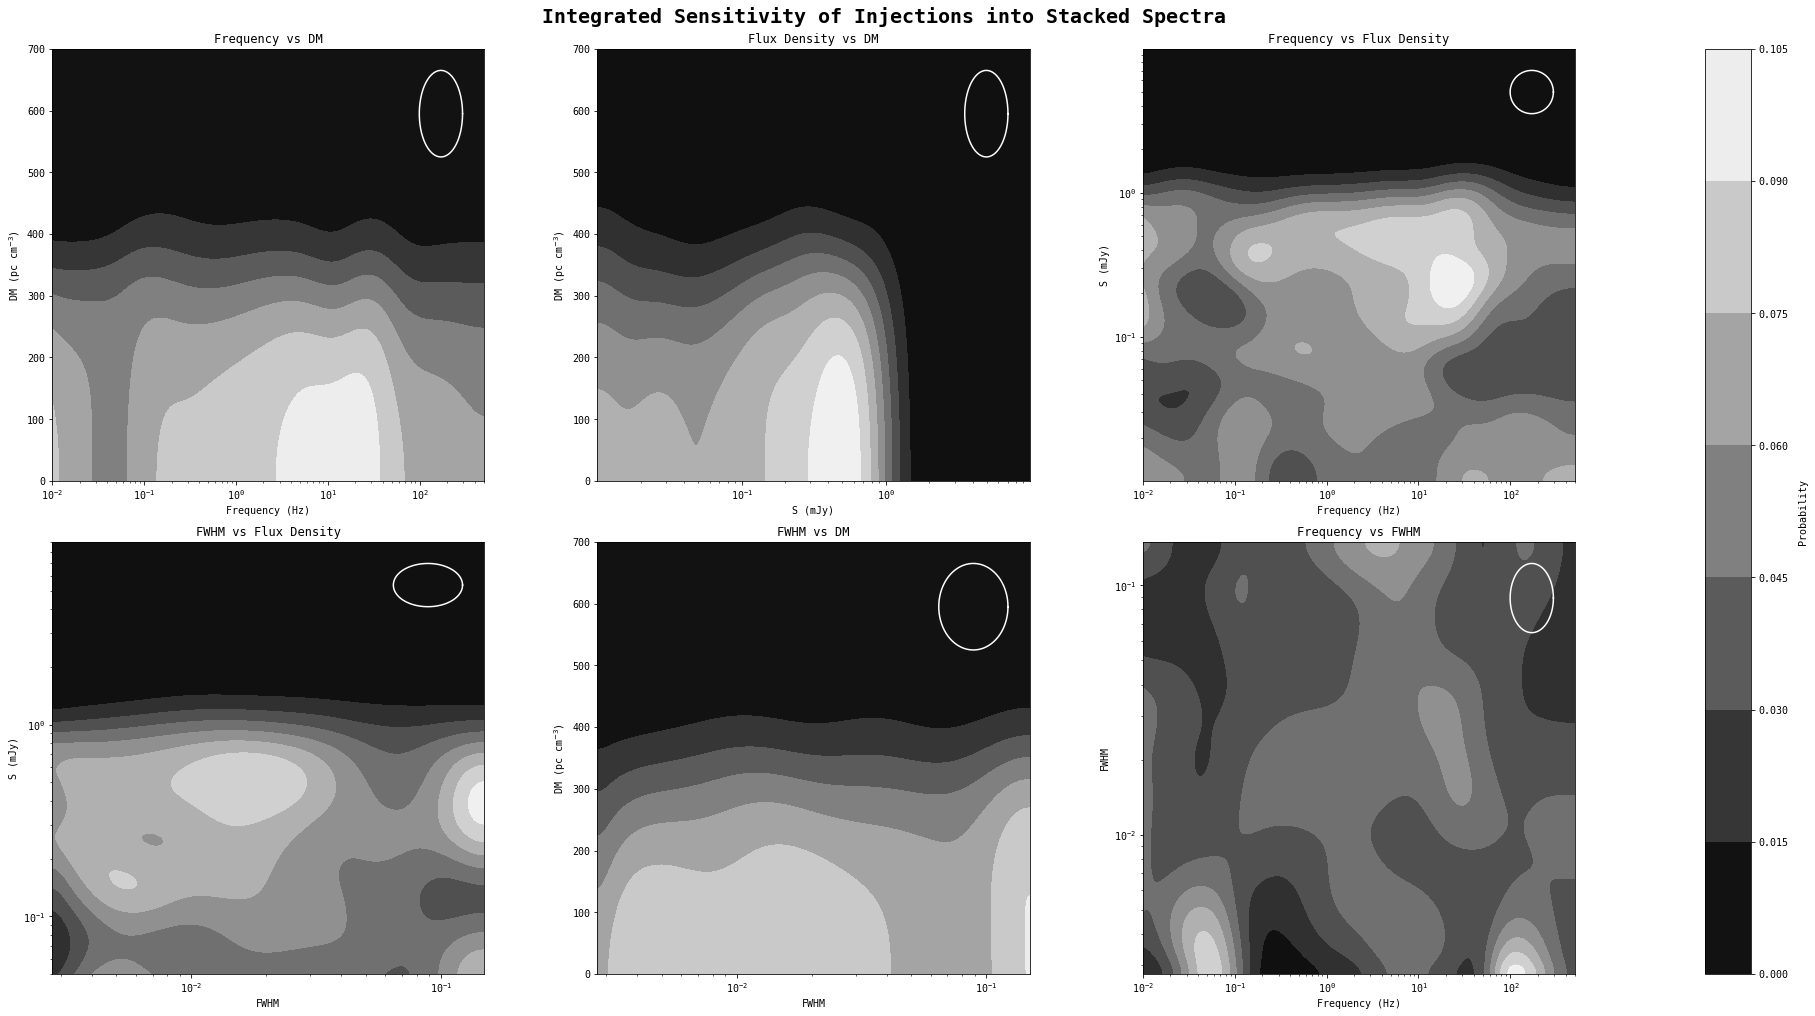

In [12]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth, cmap='gray',
                           #levels=au.make_levels(dm_f_ret_p_smooth),
                           )
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
ax[0].set_xlim(1e-2, max(f_bins))
ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth, cmap='gray',
                           #levels=au.make_levels(dm_s_ret_p_smooth), cmap='gray'
                           )
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
#ax[1].set_xlim(1e-1, max(S_bins) - 1)
ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth, cmap='gray',
                           #levels=au.make_levels(s_f_ret_p_smooth), cmap='gray'
                           )
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
ax[2].set_xlim(1e-2, max(f_bins))
#ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth, cmap='gray')
                           #levels=au.make_levels(s_fwhm_ret_p_smooth), cmap='gray')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth, cmap='gray')
                           #levels=au.make_levels(dm_fwhm_ret_p_smooth), cmap='gray')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth, cmap='gray')
                           #levels=au.make_levels(fwhm_f_ret_p_smooth), cmap='gray')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf0, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
#cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Sensitivity of Injections into Stacked Spectra', 
             fontsize=20, fontweight='bold')
plt.show()

In [19]:
import astropy.units as u

In [20]:
f_orb = 4.72e-5 * u.Hz 
P_orb = 1 / f_orb 
P_orb.to(u.hr)

<Quantity 5.88512241 h>

In [36]:
S_mask = data[:, 6] < 0.1
retrieved_mask = data[:, -1] > 0
data_low_flux = data[S_mask]
data_low_flux_retrieved = data[S_mask & retrieved_mask]
100*len(data_low_flux_retrieved) / len(data_low_flux)

0.0914933499955369

In [37]:
sigma_mask = data[:, 8] > 6.

dm_f_inj_p_smooth, _, dm_f_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

dm_s_inj_p_smooth, _, dm_s_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

s_f_inj_p_smooth, _, s_f_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

s_fwhm_inj_p_smooth, _, s_fwhm_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

dm_fwhm_inj_p_smooth, _, dm_fwhm_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

fwhm_f_inj_p_smooth, _, fwhm_f_ret_p_smooth = au.get_sensitivity(
    data[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

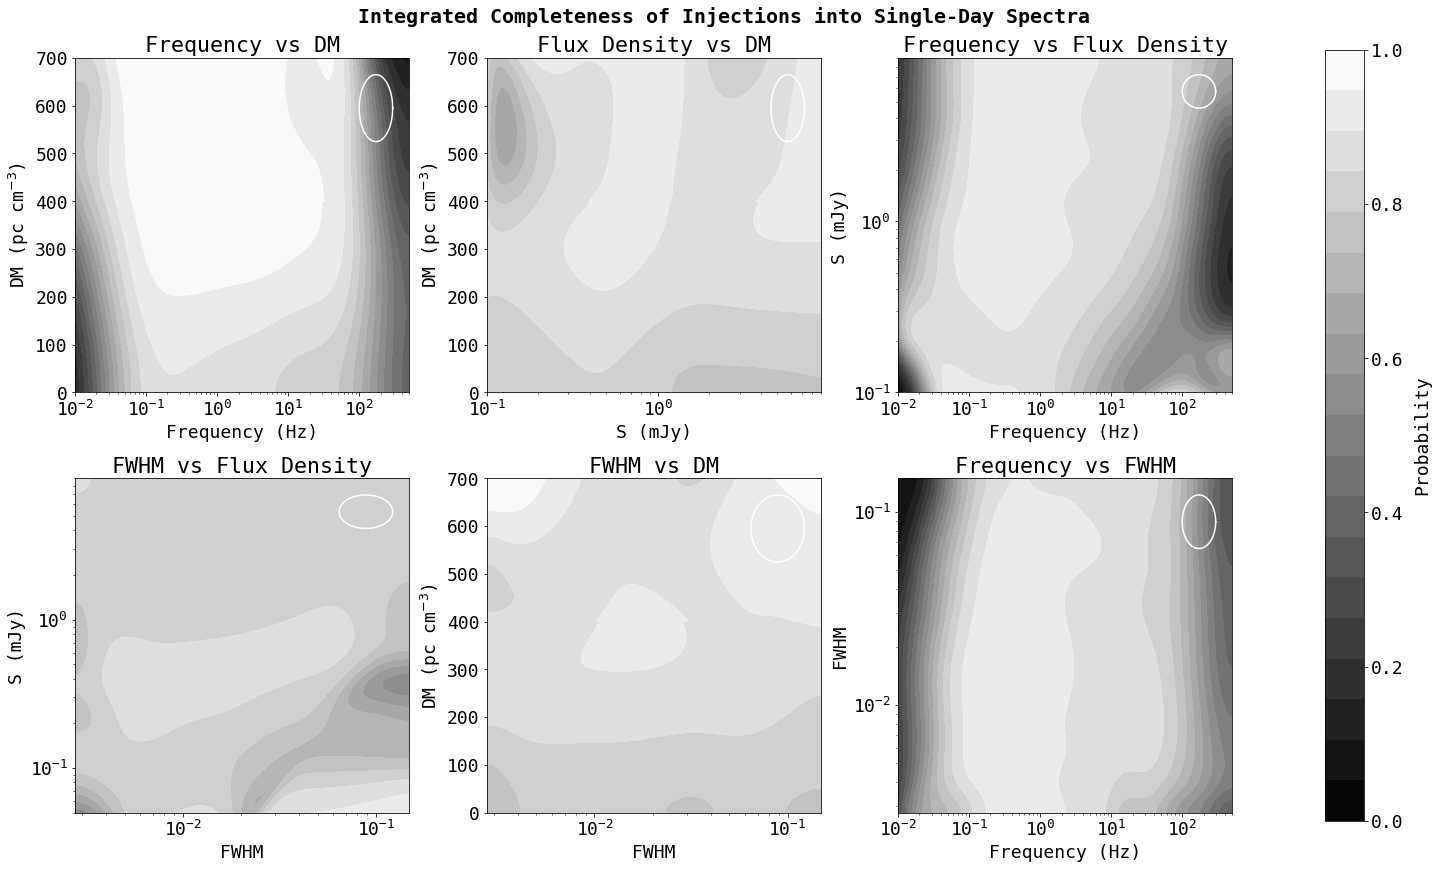

In [38]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_ret_p_smooth, 
                           levels=au.make_levels(dm_f_ret_p_smooth),cmap='gray')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
ax[0].set_xlim(1e-2, max(f_bins))
ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_ret_p_smooth, 
                           levels=au.make_levels(dm_s_ret_p_smooth), cmap='gray')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
ax[1].set_xlim(1e-1, max(S_bins) - 1)
ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_ret_p_smooth, 
                           levels=au.make_levels(s_f_ret_p_smooth), cmap='gray')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
ax[2].set_xlim(1e-2, max(f_bins))
ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_ret_p_smooth, 
                           levels=au.make_levels(s_fwhm_ret_p_smooth), cmap='gray')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_ret_p_smooth, 
                           levels=au.make_levels(dm_fwhm_ret_p_smooth), cmap='gray')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_ret_p_smooth, 
                           levels=au.make_levels(fwhm_f_ret_p_smooth), cmap='gray')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Integrated Completeness of Injections into Single-Day Spectra', 
             fontsize=20, fontweight='bold')
plt.show()

Same thing but the missed injections difference map:

In [39]:
sigma_mask = (data[:, 8] > 6.) 

_, _, dm_f_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)
_, _, dm_f_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_f_weird_harm = dm_f_ret_all - dm_f_ret_first

_, _, dm_s_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)
_, _, dm_s_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_s_weird_harm = dm_s_ret_all - dm_s_ret_first

_, _, s_f_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)
_, _, s_f_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_f_weird_harm = s_f_ret_all - s_f_ret_first

_, _, s_fwhm_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)
_, _, s_fwhm_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
s_fwhm_weird_harm = s_fwhm_ret_all - s_fwhm_ret_first

_, _, dm_fwhm_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)
_, _, dm_fwhm_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
    def_retrieval = 1,
)
dm_fwhm_weird_harm = dm_fwhm_ret_all - dm_fwhm_ret_first

_, _, fwhm_f_ret_all = au.get_sensitivity(
    data[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)
_, _, fwhm_f_ret_first = au.get_sensitivity(
    data[sigma_mask],
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d',
    def_retrieval = 1,
)
fwhm_f_weird_harm = fwhm_f_ret_all - fwhm_f_ret_first

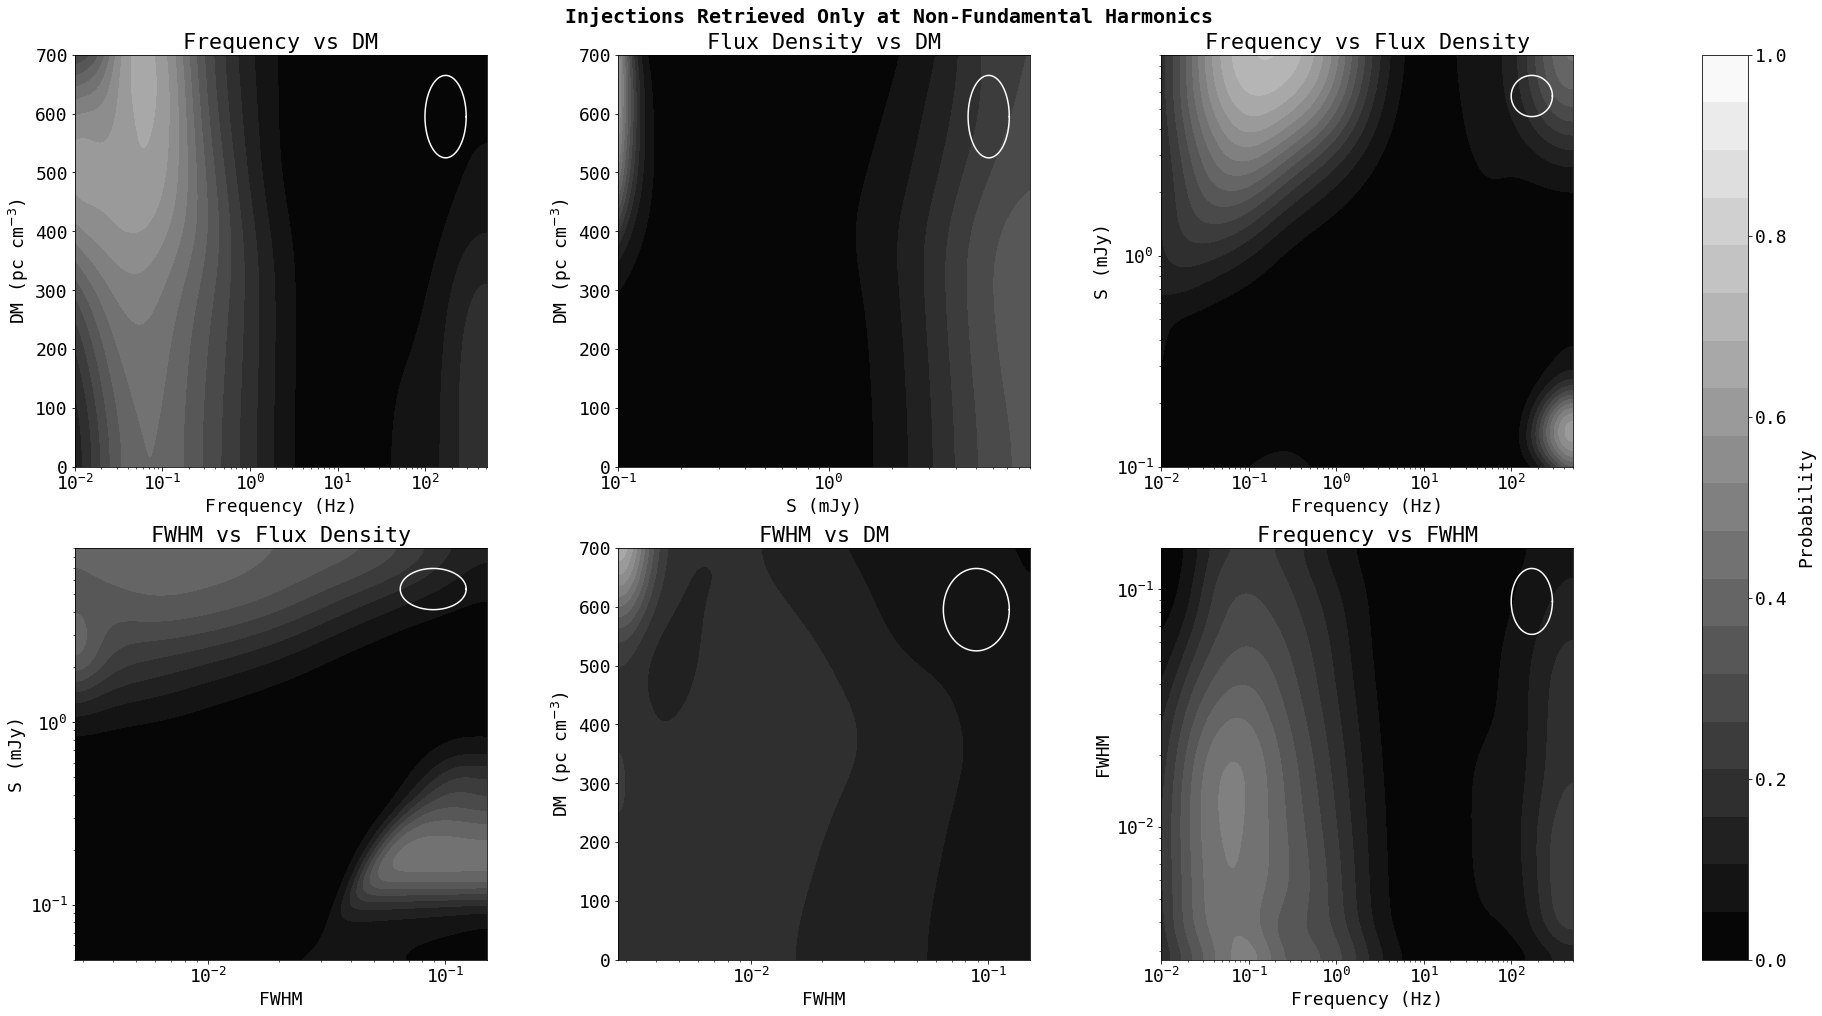

In [40]:
fig, ax = plt.subplots(2, 3, figsize=(26, 14), layout = 'constrained')
ax = ax.flatten()
import importlib
importlib.reload(au)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_weird_harm, 
                           levels=au.make_levels(dm_f_weird_harm),cmap='gray')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
ax[0].set_xlim(1e-2, max(f_bins))
ax[0].set_ylim(0, 700)
ax[0].set_box_aspect(1)
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_weird_harm, 
                           levels=au.make_levels(dm_s_weird_harm), cmap='gray')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
ax[1].set_xlim(1e-1, max(S_bins) - 1)
ax[1].set_ylim(0, 700)
ax[1].set_box_aspect(1)
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[2].contourf(f_bins[:-1], S_bins[:-1], s_f_weird_harm, 
                           levels=au.make_levels(s_f_weird_harm), cmap='gray')
ax[2].set_xscale('log')
ax[2].set_yscale('log')
ax[2].set_xlabel('Frequency (Hz)')
ax[2].set_ylabel('S (mJy)')
ax[2].set_title('Frequency vs Flux Density')
ax[2].set_box_aspect(1)
ax[2].set_xlim(1e-2, max(f_bins))
ax[2].set_ylim(1e-1, max(S_bins) - 1)
au.add_ellipse(ax[2], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[3].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_weird_harm, 
                           levels=au.make_levels(s_fwhm_weird_harm), cmap='gray')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('FWHM')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('FWHM vs Flux Density')
ax[3].set_box_aspect(1)
ax[3].set_ylim(5e-2, max(S_bins) -1 )
au.add_ellipse(ax[3], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[4].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_weird_harm, 
                           levels=au.make_levels(dm_fwhm_weird_harm), cmap='gray')
ax[4].set_xscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[4].set_title('FWHM vs DM')
ax[4].set_ylim(0, 700)
ax[4].set_xlim(fwhm_bins[0], fwhm_bins[-2])
ax[4].set_box_aspect(1)
au.add_ellipse(ax[4], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[5].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_weird_harm, 
                           levels=au.make_levels(fwhm_f_weird_harm), cmap='gray')
ax[5].set_xscale('log')
ax[5].set_yscale('log')
ax[5].set_xlabel('Frequency (Hz)')
ax[5].set_ylabel('FWHM')
ax[5].set_title('Frequency vs FWHM')
ax[5].set_box_aspect(1)
ax[5].set_ylim(fwhm_bins[0], fwhm_bins[-2])
ax[5].set_xlim(1e-2, max(f_bins))
au.add_ellipse(ax[5], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

cbar = fig.colorbar(cf5, ax=ax, location='right', pad=0.08)
cbar.set_label('Probability', labelpad=10)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

fig.suptitle('Injections Retrieved Only at Non-Fundamental Harmonics', 
             fontsize=20, fontweight='bold')
plt.show()

Now missed injections...

In [ ]:
importlib.reload(au)

<module 'scripts.analysis_utils' from '/home/rns/work/Transmissivity/scripts/analysis_utils.py'>

In [42]:
_, _, dm_f_missed = au.get_blindspots(
    data,
    *(5, 4, DM_bins, f_bins, DM_dev, f_dev),
    stype = '2d',
)

_, _, dm_s_missed = au.get_blindspots(
    data,
    *(5, 6, DM_bins, S_bins, DM_dev, S_dev),
    stype = '2d',
)

_, _, s_f_missed = au.get_blindspots(
    data,
    *(6, 4, S_bins, f_bins, S_dev, f_dev),
    stype = '2d',
)

_, _, s_fwhm_missed = au.get_blindspots(
    data,
    *(6, 7, S_bins, fwhm_bins, S_dev, FWHM_dev),
    stype = '2d',
)

_, _, dm_fwhm_missed = au.get_blindspots(
    data,
    *(5, 7, DM_bins, fwhm_bins, DM_dev, FWHM_dev),
    stype = '2d',
)

_, _, fwhm_f_missed = au.get_blindspots(
    data,
    *(7, 4, fwhm_bins, f_bins, FWHM_dev, f_dev),
    stype = '2d'
)

AttributeError: 'numpy.ndarray' object has no attribute 'contourf'

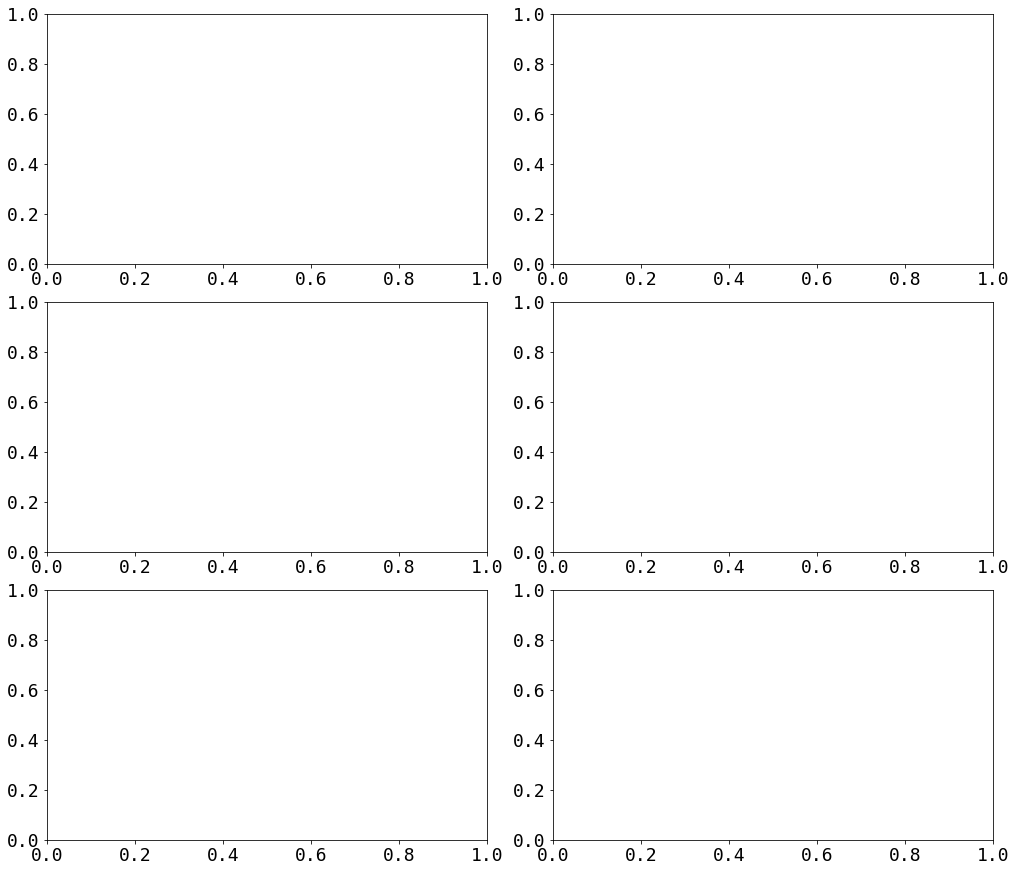

In [43]:
fig, ax = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

#f vs DM
cf0 = ax[0].contourf(f_bins[:-1], DM_bins[:-1], dm_f_missed, 
                           levels=au.make_levels(dm_f_missed),cmap='gray')
ax[0].set_xscale('log')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[0].set_title('Frequency vs DM')
ax[0].set_xlim(1e-2, max(f_bins))
ax[0].set_ylim(0, 700)
au.add_colorbar(fig, ax[0], cf0, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[0], f_bins, DM_bins, f_dev, DM_dev, x_log=True)

#S vs DM
cf1 = ax[1].contourf(S_bins[:-1], DM_bins[:-1], dm_s_missed, 
                           levels=au.make_levels(dm_s_missed), cmap='gray')
ax[1].set_xscale('log')
ax[1].set_xlabel('S (mJy)')
ax[1].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[1].set_title('Flux Density vs DM')
ax[1].set_xlim(1e-1, max(S_bins) - 1)
ax[1].set_ylim(0, 700)
au.add_colorbar(fig, ax[1], cf1, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[1], S_bins, DM_bins, S_dev, DM_dev, x_log=True)

#f vs S
cf2 = ax[3].contourf(f_bins[:-1], S_bins[:-1], s_f_missed, 
                           levels=au.make_levels(s_f_missed), cmap='gray')
ax[3].set_xscale('log')
ax[3].set_yscale('log')
ax[3].set_xlabel('Frequency (Hz)')
ax[3].set_ylabel('S (mJy)')
ax[3].set_title('Frequency vs Flux Density')
ax[3].set_xlim(1e-2, max(f_bins))
ax[3].set_ylim(1e-1, max(S_bins) - 1)
au.add_colorbar(fig, ax[3], cf2, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[3], f_bins, S_bins, f_dev, S_dev, x_log=True, y_log=True)

#FWHM vs S
cf3 = ax[4].contourf(fwhm_bins[:-1], S_bins[:-1], s_fwhm_missed, 
                           levels=au.make_levels(s_fwhm_missed), cmap='gray')
ax[4].set_xscale('log')
ax[4].set_yscale('log')
ax[4].set_xlabel('FWHM')
ax[4].set_ylabel('S (mJy)')
ax[4].set_title('FWHM vs Flux Density')
ax[4].set_ylim(5e-2, max(S_bins) -1 )
au.add_colorbar(fig, ax[4], cf3, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[4], fwhm_bins, S_bins, FWHM_dev, S_dev, x_log=True, y_log=True)

#FWHM vs DM
cf4 = ax[2, 0].contourf(fwhm_bins[:-1], DM_bins[:-1], dm_fwhm_missed, 
                           levels=au.make_levels(dm_fwhm_missed), cmap='gray')
ax[2, 0].set_xscale('log')
ax[2, 0].set_xlabel('FWHM')
ax[2, 0].set_ylabel(r'DM (pc cm$^{-3}$)')
ax[2, 0].set_title('FWHM vs DM')
ax[2, 0].set_ylim(0, 700)
au.add_colorbar(fig, ax[2, 0], cf4, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[2, 0], fwhm_bins, DM_bins, FWHM_dev, DM_dev, x_log=True)

#f vs FWHM
cf5 = ax[2, 1].contourf(f_bins[:-1], fwhm_bins[:-1], fwhm_f_missed, 
                           levels=au.make_levels(fwhm_f_missed), cmap='gray')
ax[2, 1].set_xscale('log')
ax[2, 1].set_yscale('log')
ax[2, 1].set_xlabel('Frequency (Hz)')
ax[2, 1].set_ylabel('FWHM')
ax[2, 1].set_title('Frequency vs FWHM')
ax[2, 1].set_xlim(1e-2, max(f_bins))
au.add_colorbar(fig, ax[2, 1], cf5, tick_locs = [0.2, 0.4, 0.6, 0.8])
au.add_ellipse(ax[2, 1], f_bins, fwhm_bins, f_dev, FWHM_dev, x_log=True, y_log=True)

fig.suptitle('Missed Injections in Single Day Power Spectra', fontsize=14, fontweight='bold')
fig.get_layout_engine().set(h_pad=0.1, hspace=0.15, w_pad=0.1, wspace=0.1, 
                            rect=[3.95])
plt.show()

Everything below this is extremely work in progress...

In [ ]:
def gradient_correlation(data, x_bins, y_bins, x_log=False, y_log=False):

    x = np.log(x_bins[:-1]) if x_log else x_bins[:-1]
    y = np.log(y_bins[:-1]) if y_log else y_bins[:-1]

    grad_y, grad_x = np.gradient(data, y, x)
    
    gx = grad_x.ravel()
    gy = grad_y.ravel()
    mask = np.isfinite(gx) & np.isfinite(gy)
    
    r = np.corrcoef(gx[mask], gy[mask])[1]
    return r, grad_x, grad_y

pairs = [
    ('Frequency', 'DM',        dm_f_ret_p_smooth,   f_bins,    DM_bins,   True,  False),
    ('S',         'DM',        dm_s_ret_p_smooth,   S_bins,    DM_bins,   True,  False),
    ('Frequency', 'S',         s_f_ret_p_smooth,    f_bins,    S_bins,    True,  True),
    ('FWHM',      'S',         s_fwhm_ret_p_smooth, fwhm_bins, S_bins,    True,  True),
    ('FWHM',      'DM',        dm_fwhm_ret_p_smooth,fwhm_bins, DM_bins,   True,  False),
    ('Frequency', 'FWHM',      fwhm_f_ret_p_smooth, f_bins,    fwhm_bins, True,  True),
]

print(f"{'Parameter Pair':<25} {'Gradient Correlation':>20}")
print("-" * 47)
for x_name, y_name, data, x_bins_, y_bins_, x_log, y_log in pairs:
    r, _, _ = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    print(f"{x_name + ' vs ' + y_name:<25} {r:>20.4f}")

Parameter Pair            Gradient Correlation
-----------------------------------------------
Frequency vs DM                         0.5124
S vs DM                                -0.4337
Frequency vs S                         -0.3725
FWHM vs S                              -0.6971
FWHM vs DM                              0.2697
Frequency vs FWHM                      -0.2070


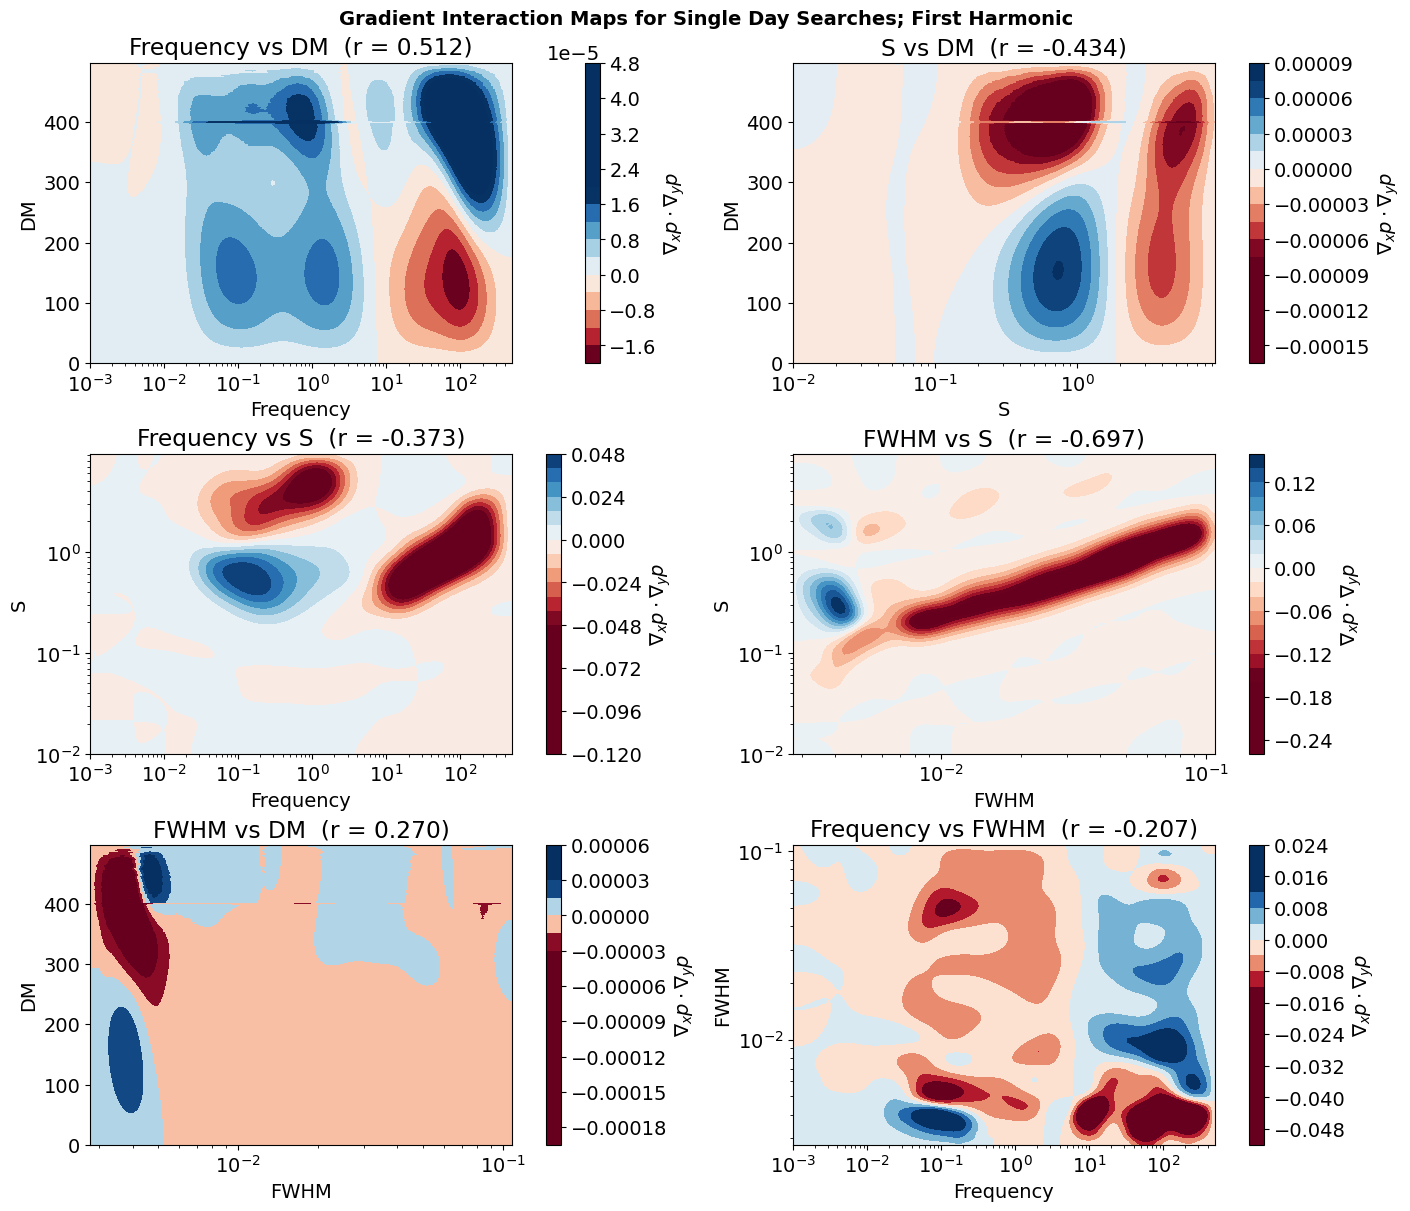

In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)

for ax, (x_name, y_name, data, x_bins_, y_bins_, x_log, y_log) in zip(ax.ravel(), pairs):
    r, grad_x, grad_y = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    interaction = grad_x * grad_y
    x_vals = x_bins_[:-1]
    y_vals = y_bins_[:-1]
    
    vmax = np.nanpercentile(np.abs(interaction), 95)
    cf = ax.contourf(x_vals, y_vals, interaction, levels=20, 
                     cmap='RdBu', vmin=-vmax, vmax=vmax)
    fig.colorbar(cf, ax=ax, label='$\\nabla_x p \\cdot \\nabla_y p$')
    
    if x_log: ax.set_xscale('log')
    if y_log: ax.set_yscale('log')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f'{x_name} vs {y_name}  (r = {r:.3f})')

fig.suptitle('Gradient Interaction Maps for Single Day Searches; First Harmonic', 
             fontsize=14, fontweight='bold')
plt.show()

Parameter Pair            Gradient Correlation
-----------------------------------------------
Frequency vs DM                         0.5169
S vs DM                                -0.3816
Frequency vs S                         -0.3682
FWHM vs S                              -0.8169
FWHM vs DM                              0.3837
Frequency vs FWHM                      -0.2850


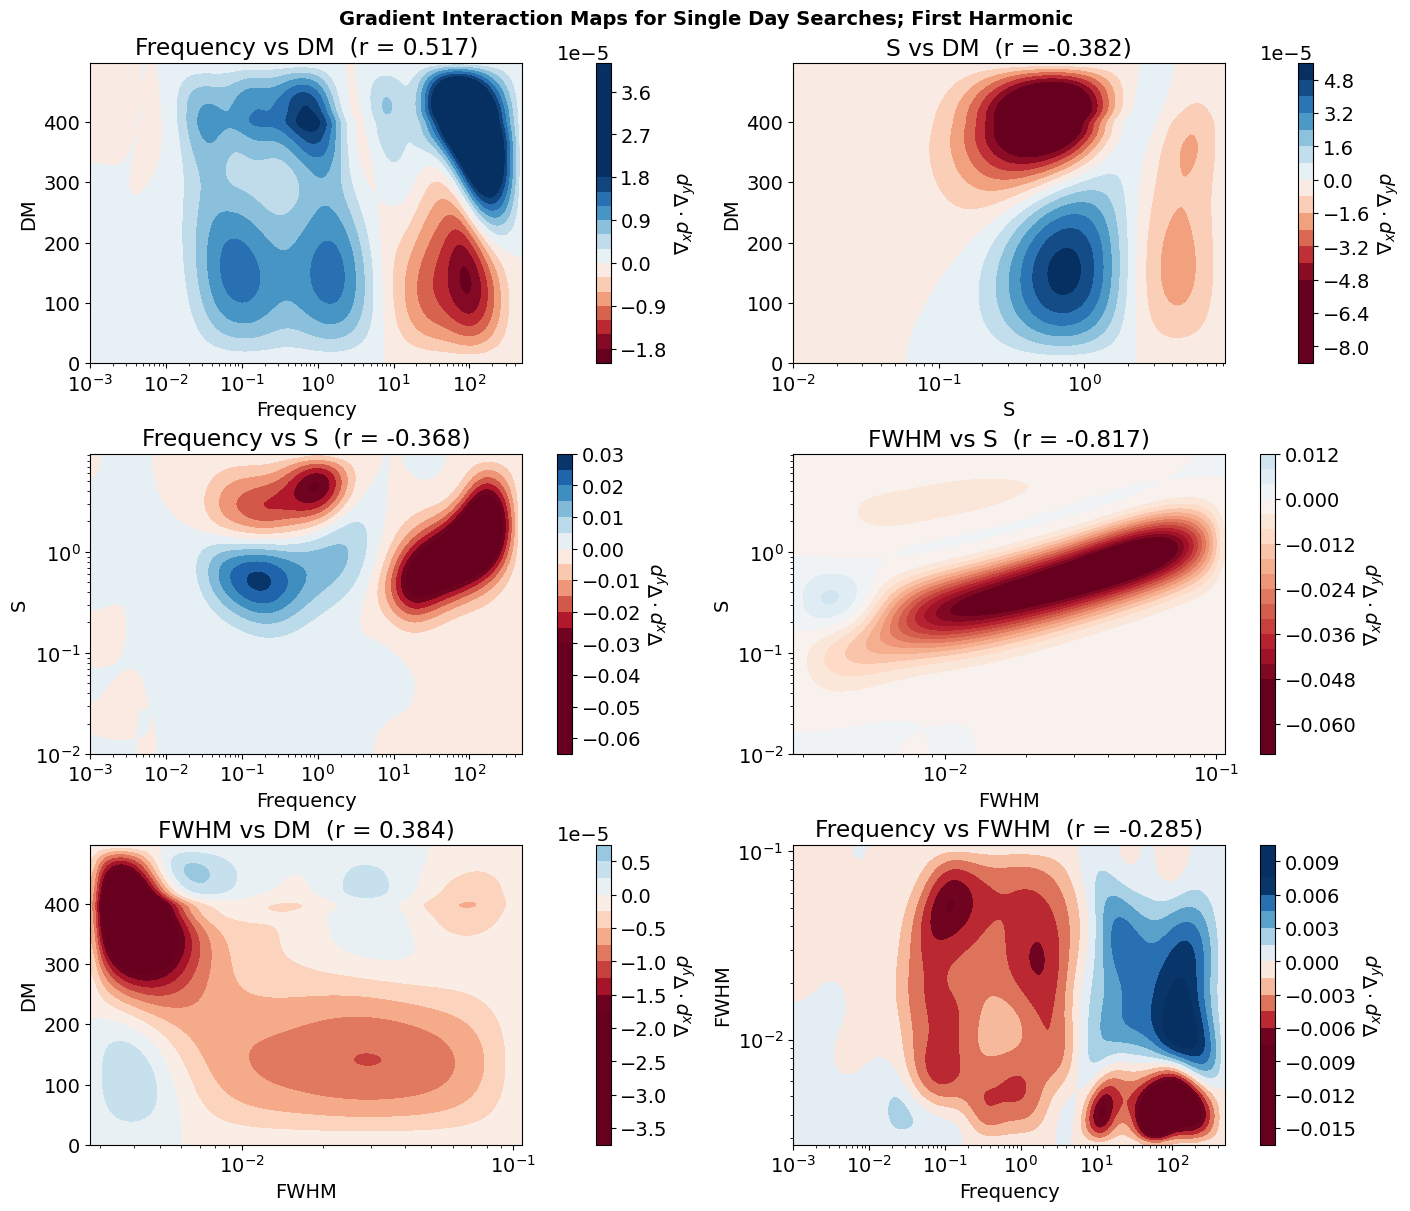

In [ ]:
from scipy.ndimage import gaussian_filter

SIGMA = 10.0  # Gaussian smoothing parameter  adjust as needed

def gradient_correlation(data, x_bins, y_bins, x_log=False, y_log=False, sigma=SIGMA):
    if sigma > 0:
        data = gaussian_filter(data, sigma=sigma)
    x = np.log(x_bins[:-1]) if x_log else x_bins[:-1]
    y = np.log(y_bins[:-1]) if y_log else y_bins[:-1]
    grad_y, grad_x = np.gradient(data, y, x)
    
    gx = grad_x.ravel()
    gy = grad_y.ravel()
    mask = np.isfinite(gx) & np.isfinite(gy)
    
    r = np.corrcoef(gx[mask], gy[mask])[1]
    return r, grad_x, grad_y

pairs = [
    ('Frequency', 'DM',        dm_f_ret_p_smooth,   f_bins,    DM_bins,   True,  False),
    ('S',         'DM',        dm_s_ret_p_smooth,   S_bins,    DM_bins,   True,  False),
    ('Frequency', 'S',         s_f_ret_p_smooth,    f_bins,    S_bins,    True,  True),
    ('FWHM',      'S',         s_fwhm_ret_p_smooth, fwhm_bins, S_bins,    True,  True),
    ('FWHM',      'DM',        dm_fwhm_ret_p_smooth,fwhm_bins, DM_bins,   True,  False),
    ('Frequency', 'FWHM',      fwhm_f_ret_p_smooth, f_bins,    fwhm_bins, True,  True),
]

print(f"{'Parameter Pair':<25} {'Gradient Correlation':>20}")
print("-" * 47)
for x_name, y_name, data, x_bins_, y_bins_, x_log, y_log in pairs:
    r, _, _ = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    print(f"{x_name + ' vs ' + y_name:<25} {r:>20.4f}")

# --- First pass: compute all interactions to find global color scale ---
interactions = []
results = []
for x_name, y_name, data, x_bins_, y_bins_, x_log, y_log in pairs:
    r, grad_x, grad_y = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    interaction = grad_x * grad_y
    interactions.append(interaction)
    results.append((x_name, y_name, r, interaction, x_bins_, y_bins_, x_log, y_log))

global_vmax = np.nanpercentile(np.abs(np.concatenate([i.ravel() for i in interactions])), 95)

fig, ax = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
for ax, (x_name, y_name, data, x_bins_, y_bins_, x_log, y_log) in zip(ax.ravel(), pairs):
    r, grad_x, grad_y = gradient_correlation(data, x_bins_, y_bins_, x_log, y_log)
    interaction = grad_x * grad_y
    x_vals = x_bins_[:-1]
    y_vals = y_bins_[:-1]

    vmax = np.nanpercentile(np.abs(interaction), 95)
    cf = ax.contourf(x_vals, y_vals, interaction, levels=20,
                     cmap='RdBu', vmin=-vmax, vmax=vmax)
    fig.colorbar(cf, ax=ax, label='$\\nabla_x p \\cdot \\nabla_y p$')

    if x_log: ax.set_xscale('log')
    if y_log: ax.set_yscale('log')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f'{x_name} vs {y_name}  (r = {r:.3f})')

fig.suptitle('Gradient Interaction Maps for Single Day Searches; First Harmonic',
             fontsize=14, fontweight='bold')
plt.show()